# Load Data & imports

In [30]:
# Imports und small helper: prüfe, ob wichtige Pakete vorhanden sind und zeige eine kurze Nachricht,
# falls etwas fehlt, installiere es in deiner Virtualenv (zsh):
# pip install ipywidgets scikit-image matplotlib imageio
%load_ext autoreload
%autoreload 2

import pickle
import gzip
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
import ipywidgets as widgets
from ipywidgets import IntSlider, FloatSlider, VBox
import os

print('Imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK


### Helper functions

In [31]:
def load_zipped_pickle(filename):
    with gzip.open(filename, 'rb') as f:
        loaded_object = pickle.load(f)
        return loaded_object

In [32]:
def save_zipped_pickle(obj, filename):
    with gzip.open(filename, 'wb') as f:
        pickle.dump(obj, f, 2)

Example format of sample: { 'name': 'AC8ASN45B9', 'video': array([...], dtype='uint8'), 'box': array([...], dtype='bool'), 'label': array([...], dtype='bool'), 'frames': [41, 65, 167], 'dataset': 'amateur' }

In [33]:
# Pfad zu train.pkl anpassen falls nötig
pkl_path = './data/raw/train.pkl'
if not os.path.exists(pkl_path):
    raise FileNotFoundError(f'{pkl_path} nicht gefunden im aktuellen Verzeichnis: {os.getcwd()}')
# Get entire dataset
data = load_zipped_pickle(pkl_path)

print('Number of samples:', len(data))

# Inspect a few samples (up to 3)
for i, sample in enumerate(data[:3]):
    print(f'Sample {i} name:', sample.get('name'))
    vid = sample.get('video')
    lab = sample.get('label')
    box = sample.get('box')
    print('  video: dtype=', getattr(vid, 'dtype', None), ' shape=', getattr(vid, 'shape', None))
    print('  label: dtype=', getattr(lab, 'dtype', None), ' shape=', getattr(lab, 'shape', None))
    print('  box:   dtype=', getattr(box, 'dtype', None), ' shape=', getattr(box, 'shape', None))
    print('  frames:', sample.get('frames'))

Number of samples: 65
Sample 0 name: D47OR19ANJ
  video: dtype= uint8  shape= (112, 112, 334)
  label: dtype= bool  shape= (112, 112, 334)
  box:   dtype= bool  shape= (112, 112)
  frames: [15, 59, 143]
Sample 1 name: IMNKTJV3OI
  video: dtype= uint8  shape= (112, 112, 177)
  label: dtype= bool  shape= (112, 112, 177)
  box:   dtype= bool  shape= (112, 112)
  frames: [2, 47, 79]
Sample 2 name: YSCCEISFRH
  video: dtype= uint8  shape= (112, 112, 195)
  label: dtype= bool  shape= (112, 112, 195)
  box:   dtype= bool  shape= (112, 112)
  frames: [18, 83, 131]


# Visualization of Data

In [34]:
# Interaktiver Viewer mit ipywidgets + matplotlib
# Funktion zum Anzeigen eines Frames mit Masken-Overlay und Konturen
def show_frame(sample_idx=0, t=0, alpha=0.5, downsample=1):
    sample = data[sample_idx]
    video = sample['video']  # video shape (H, W, T)
    label = sample.get('label')
    box = sample.get('box')

    # handle possible color channels
    img = video[:, :, t]

    mask = None
    if label is not None:
        mask = label[:, :, t].astype(bool)

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')

    # mask overlay (red) — uses per-pixel RGBA so alpha only affects mask area
    if mask is not None:
        h, w = mask.shape
        rgba = np.zeros((h, w, 4), dtype=np.float32)
        rgba[..., 0] = 1.0                      # red channel
        rgba[..., 3] = mask.astype(float) * alpha  # alpha channel only where mask True
        plt.imshow(rgba, interpolation='nearest')
        # draw contours for better visibility
        try:
            contours = measure.find_contours(mask.astype(np.uint8), 0.5)
            for contour in contours:
                plt.plot(contour[:, 1], contour[:, 0], linewidth=1.2, color='yellow')
        except Exception:
            # falls find_contours fehlschlägt, ignoriere
            pass

    # box overlay (green) — assume box is a 2D bool mask (H, W)
    if box is not None:
        b = np.asarray(box).astype(bool)
        # make overlay mask
        rgba_box = np.zeros((b.shape[0], b.shape[1], 4), dtype=np.float32)
        rgba_box[..., 1] = 1.0  # green channel
        rgba_box[..., 3] = b.astype(float) * alpha / 2
        plt.imshow(rgba_box, interpolation='nearest')

    plt.title(f"{sample.get('name', 'sample')} frame {t}. Dataset: {sample['dataset']}")
    plt.axis('off')
    plt.show()

# Widgets: sample index, frame index (aktualisiert sich beim Wechsel des Samples), alpha
n_samples = len(data)
sample_slider = IntSlider(min=0, max=n_samples-1, value=0, description='sample')
# initial max für frame von sample 0
initial_max_frame = data[0]['video'].shape[2] - 1
frame_slider = IntSlider(min=0, max=initial_max_frame, value=0, description='frame')
alpha_slider = FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5, description='alpha')
downsample_slider = IntSlider(min=1, max=8, step=1, value=1, description='down')

def _on_sample_change(change):
    if change['name'] == 'value':
        s = change['new']
        maxf = data[s]['video'].shape[2] - 1
        frame_slider.max = maxf
        frame_slider.value = 0

sample_slider.observe(_on_sample_change, names='value')

out = widgets.interactive_output(show_frame, {'sample_idx': sample_slider, 't': frame_slider, 'alpha': alpha_slider, 'downsample': downsample_slider})
ui = VBox([sample_slider, frame_slider, alpha_slider, downsample_slider])
display(ui, out)


Output()

# Implement UNet Architecture

In [35]:
# PyTorch UNet implementation + Dice loss + small training/eval scaffolding
# Install instructions (if needed): pip install torch torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List


class DoubleConv(nn.Module):
    """(conv => BN => ReLU) * 2"""
    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        if not mid_ch:
            mid_ch = out_ch
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv. Uses bilinear upsampling by default.

    NOTE: fixed channel arithmetic: after upsampling x1 (in_ch channels) we concatenate
    the encoder feature x2 (out_ch channels) -> conv input channels = in_ch + out_ch
    """
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        self.bilinear = bilinear
        if bilinear:
            # simple upsample; channel count of x1 remains in_ch
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            conv_in = in_ch + out_ch
            self.conv = DoubleConv(conv_in, out_ch, mid_ch=conv_in // 2)
        else:
            # ConvTranspose2d that halves channels of x1 to match expected concat shape
            # Here we make x1 -> in_ch//2 so that after concat with x2 (out_ch) we get in_ch//2 + out_ch
            # but to keep it simple set transpose to produce out_ch channels then conv gets out_ch + out_ch
            self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
            conv_in = out_ch + out_ch
            self.conv = DoubleConv(conv_in, out_ch)

    def forward(self, x1, x2):
        # x1: decoder feature (to be upsampled), x2: encoder skip connection
        x1 = self.up(x1)
        # pad x1 to the size of x2 (in case of odd sizes)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch = 2):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=1, features: List[int] = None, bilinear=True):
        super().__init__()
        if features is None:
            features = [64, 128, 256, 512]
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, features[0])
        self.down1 = Down(features[0], features[1])
        self.down2 = Down(features[1], features[2])
        self.down3 = Down(features[2], features[3])

        factor = 2 if bilinear else 1
        self.down4 = Down(features[3], features[3] * factor)

        self.up1 = Up(features[3] * factor, features[3], bilinear)
        self.up2 = Up(features[3], features[2], bilinear)
        self.up3 = Up(features[2], features[1], bilinear)
        self.up4 = Up(features[1], features[0], bilinear)
        self.outc = OutConv(features[0], n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def logits_to_mask(logits, threshold=0.5):
        """
        returns integer mask:
        - for single-channel output -> binary mask (B,H,W) with 0/1 using threshold
        - for multi-channel (C>1) -> class ids (B,H,W) via argmax (0=background,1=foreground)
        """
        '''if logits.shape[1] == 1:
            probs = torch.sigmoid(logits)
            return (probs > threshold).long().squeeze(1)'''
        probs = torch.softmax(logits, dim=1)
        return torch.argmax(probs, dim=1)
    
    def predict_mask(self, x, threshold=0.5):
        logits = self.forward(x)
        return UNet.logits_to_mask(logits, threshold=threshold)


# Dice Loss for binary segmentation
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        # preds: logits -> apply sigmoid
        preds = torch.sigmoid(preds)
        preds = preds.contiguous().view(preds.shape[0], -1)
        targets = targets.contiguous().view(targets.shape[0], -1).float()

        intersection = (preds * targets).sum(dim=1)
        union = preds.sum(dim=1) + targets.sum(dim=1)
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        loss = 1 - dice
        return loss.mean()


# Utility: initialize weights
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            nn.init.kaiming_normal_(m.weight)
            if getattr(m, 'bias', None) is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)


# Training functions

In [36]:
from tqdm.auto import tqdm
# Training scaffold (to be adapted to your dataset loader)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(dataloader, desc=f'Training next epoch', leave=False)
    for imgs, masks in pbar:
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

        pbar.set_postfix({'loss': loss.item()})

    return running_loss / len(dataloader.dataset)


def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    pbar = tqdm(dataloader, desc='Validation', leave=False)
    with torch.no_grad():
        for imgs, masks in pbar:
            imgs = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            loss = criterion(preds, masks)
            running_loss += loss.item() * imgs.size(0)

            pbar.set_postfix({'loss': loss.item()})
    return running_loss / len(dataloader.dataset)


print('# UNet cell loaded: implement dataset & dataloaders, then use the scaffold to train.')


# UNet cell loaded: implement dataset & dataloaders, then use the scaffold to train.


# Data structure for frames

In [37]:
# Zelle: PyTorch Dataset (flache Listen)
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class FramesDataset(Dataset):
    def __init__(self, frames, masks):
        """
        frames: list or array of np.ndarray images, shape (H,W) (values 0..1 float)
        masks:  list or array of np.ndarray masks, shape (H,W) (values 0/1)
        """
        assert len(frames) == len(masks)
        self.frames = frames
        self.masks = masks

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        img = np.asarray(self.frames[idx])
        mask = np.asarray(self.masks[idx])

        # Normalize image to 0..1 float
        img = img.astype('float32') / 255.0

        # to torch tensors: (H,W) and mask (H,W)
        img_t = torch.from_numpy(img.transpose(2,0,1)).float() # C,H,W (For Conv2d)
        mask_t = torch.from_numpy(mask[...,0]).long()          # H,W (Long for CrossEntropy)
        return img_t, mask_t

# Train model

In [38]:
# For now, data contains all videos labeled by amateurs. We do a 80/20 train/val split here.
from utilities import make_train_test_split

# Split data into train and validation sets. We take validation data only from expert labeled videos.
# test_ratio refers to the fraction of expert labeled videos, NOT total videos.
train_data, val_data = make_train_test_split(data, test_ratio=0.2, random_seed=42)

# preprocess training data and validation data: extract frames and masks from data dicts
from utilities import preprocess_train_data
print("Preprocessing train data...")
names, frames, masks = preprocess_train_data(train_data)
val_names, val_frames, val_masks = preprocess_train_data(val_data)
# Make frames and masks single channel (H,W) So list has dimension (N, H, W) not (N, H, W, 1)
print(f"Processed {len(names)} training samples.")

# set up dataset and dataloader
train_ds = FramesDataset(frames, masks)
val_ds = FramesDataset(val_frames, val_masks)
print(f'Training Dataset size: {len(train_ds)}')
print(f'Validation Dataset size: {len(val_ds)}')

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

# Set up model, optimizer, criterion, device
model = UNet(n_channels=1, n_classes=2)
initialize_weights(model)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device', device)
model = model.to(device)

Preprocessing train data...


100%|██████████| 3/3 [00:00<00:00, 72.30it/s]



Processed 186 training samples.
Training Dataset size: 186
Validation Dataset size: 9
Using device cpu
Using device cpu


Overall Training:   0%|          | 0/5 [00:00<?, ?it/s]

Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/5 — train_loss: 0.188123, val_loss: 0.062099


Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 4/5 — train_loss: 0.026765, val_loss: 0.030651


Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 5/5 — train_loss: 0.024043, val_loss: 0.037262


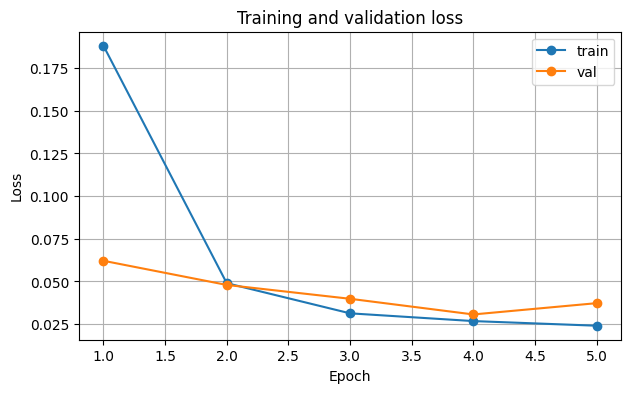

In [ ]:
# Train for 10 epochs and plot epoch losses
epochs = 5
train_losses = []
val_losses = []

pbar = tqdm(range(1, epochs+1), desc='Overall Training')
for epoch in pbar:
    train_loss = train_one_epoch(model, train_loader, optim, criterion, device)
    val_loss = eval_one_epoch(model, val_loader, criterion, device)  # using val_loader
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'Epoch {epoch}/{epochs} — train_loss: {train_loss:.6f}, val_loss: {val_loss:.6f}')
    pbar.set_postfix({'train_loss': train_loss, 'val_loss': val_loss})
torch.save(model.state_dict(), 'unet_mitral_valve.pth')
print('Model saved to unet_mitral_valve.pth')
# Plot losses
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), train_losses, marker='o', label='train')
plt.plot(range(1, epochs+1), val_losses, marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True)
plt.show()

# Model evaluation

We have to be carefull how to scale our data when making predictions. Our model is trained to make predictions for 256 x 256 images. So to get a prediction for arbitrary images, we have to 1. rescale the image 2. get prediction mask 3. do the inverse rescaling of the mask to get prediction for the original image.

We first compute median Jaccard Index on val_data an then visualize the predicted masks on one of the videos in val_data

In [45]:
torch.save(model.state_dict(), 'unet_weights.pth')


In [44]:
# Compute median Jaccard Index (IoU) on val_loader (frame-level)
import numpy as np

model.eval()
iou_scores = []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)  # (B,H,W)
        # per-sample IoU
        for p, t in zip(preds, masks):
            p_bin = p.bool()
            t_bin = t.bool()
            inter = (p_bin & t_bin).sum().item()
            union = (p_bin | t_bin).sum().item()
            if union == 0:
                iou = 1.0  # both empty
            else:
                iou = inter / union
            iou_scores.append(iou)

median_iou = float(np.median(iou_scores)) if iou_scores else float('nan')
print(f"Median IoU on val_loader: {median_iou:.4f} (n={len(iou_scores)} frames)")


Median IoU on val_loader: 0.2433 (n=9 frames)


Sample name: YEZ7BPLZW0
Video shape: (587, 647, 76) dtype: uint8
DEBUG: Original image shape: (587, 647), dtype: float32, range: [0.000, 0.992]
DEBUG: Resized image shape: (256, 256), range: [0.000, 0.981]
DEBUG: Input tensor shape: torch.Size([1, 1, 256, 256]), range: [0.000, 0.981]
DEBUG: Logits shape: torch.Size([1, 2, 256, 256]), range: [-3.422, 11.141]
DEBUG: Logits unique values sample: tensor([-3.4225, -3.4175, -3.4154, -3.3954, -3.3908, -3.3904, -3.3880, -3.3816,
        -3.3812, -3.3793])
DEBUG: Logits channel 0 (background) range: [-1.957, 11.141]
DEBUG: Logits channel 1 (foreground) range: [-3.422, 1.324]
DEBUG: Mean difference (ch1 - ch0): -4.707
DEBUG: Mask shape: torch.Size([1, 256, 256]), unique values: tensor([0, 1])
DEBUG: Mask numpy shape: (256, 256), unique: [0 1], sum: 754
DEBUG: Logits shape: torch.Size([1, 2, 256, 256]), range: [-3.422, 11.141]
DEBUG: Logits unique values sample: tensor([-3.4225, -3.4175, -3.4154, -3.3954, -3.3908, -3.3904, -3.3880, -3.3816,
     

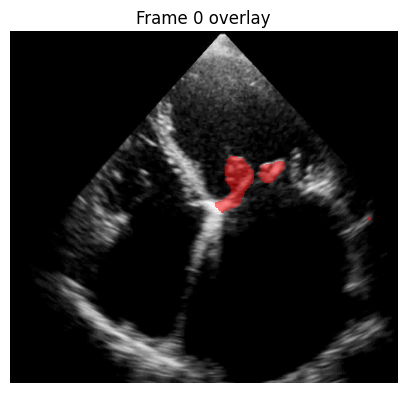

In [41]:
from utilities import get_mask_from_image
import cv2
# Inference with slider: predict masks for all frames of first validation video and browse them
sample = val_data[0]
video = sample['video']  # shape assumed (H, W, T)
print('Sample name:', sample.get('name'))
print('Video shape:', video.shape, 'dtype:', video.dtype)

H, W, T = video.shape

# ensure model on device and eval
model = model.to(device)
model.eval()

img = video[..., 0].astype('float32') / 255.0  # (H,W) 
mask = get_mask_from_image(img, model, 256, 256)  # (H,W) binary

import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
#plt.imshow(cv2.resize(img, (256, 256), interpolation=cv2.INTER_LINEAR), cmap='gray')
plt.imshow(img, cmap='gray')
rgba = np.zeros((H, W, 4), dtype=np.float32)
rgba[..., 0] = 1.0
rgba[..., 3] = mask.astype(float) * 0.5
plt.imshow(rgba, interpolation='nearest')
plt.title(f"Frame 0 overlay")
plt.axis('off')
plt.show()

In [ ]:
from utilities import get_mask_from_image
# Inference with slider: predict masks for all frames of first validation video and browse them
sample = val_data[1]
video = sample['video']  # shape assumed (H, W, T)
print('Sample name:', sample.get('name'))
print('Video shape:', video.shape, 'dtype:', video.dtype)

H, W, T = video.shape

# ensure model on device and eval
model = model.to(device)
model.eval()

# run inference for all frames (single-channel input assumed)
masks_pred = []

with torch.no_grad():
    for i in range(0, T//2):
        frame = video[..., i].astype('float32') / 255.0  # (H,W) 
        mask = get_mask_from_image(frame, model, 256, 256)  # (H,W) binary
        masks_pred.append(mask)

masks_pred = np.stack(masks_pred, axis=0)  # (T,H,W)
print('Predicted masks shape (T,H,W):', masks_pred.shape)

# slider to browse frames with overlay
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import IntSlider

frame_slider = IntSlider(min=0, max=T-1, value=0, description='frame')

def show_pred_frame(t):
    plt.figure(figsize=(5,5))
    plt.imshow(video[..., t], cmap='gray')
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    rgba[..., 0] = 1.0
    rgba[..., 3] = masks_pred[t].astype(float) * 0.5
    plt.imshow(rgba, interpolation='nearest')
    plt.title(f"Frame {t} overlay")
    plt.axis('off')
    plt.show()

widgets.interact(show_pred_frame, t=frame_slider)

Sample name: YEZ7BPLZW0
Video shape: (587, 647, 76) dtype: uint8
Predicted masks shape (T,H,W): (76, 587, 647)
Predicted masks shape (T,H,W): (76, 587, 647)


interactive(children=(IntSlider(value=0, description='frame', max=75), Output()), _dom_classes=('widget-intera…

<function __main__.show_pred_frame(t)>

In [43]:
# Visualize val_loader predictions vs labels with a slider (all frames)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import IntSlider

model.eval()
all_imgs = []
all_gts = []
all_preds = []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)  # (B,H,W)
        # move to cpu numpy
        all_imgs.append(imgs.cpu().numpy())        # (B,1,H,W)
        all_gts.append(masks.cpu().numpy())        # (B,H,W)
        all_preds.append(preds.cpu().numpy())      # (B,H,W)

# stack along batch dimension
imgs_np = np.concatenate(all_imgs, axis=0)   # (N,1,H,W)
gts_np = np.concatenate(all_gts, axis=0)     # (N,H,W)
preds_np = np.concatenate(all_preds, axis=0) # (N,H,W)
N, _, H, W = imgs_np.shape
print(f'Collected {N} frames from val_loader for visualization: shape (N,H,W)=({N},{H},{W})')

frame_slider = IntSlider(min=0, max=N-1, value=0, description='frame')

def show_overlay(i):
    img = imgs_np[i, 0]  # assume single channel
    gt = gts_np[i]
    pr = preds_np[i]
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap='gray')
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    # green = label, red = prediction
    rgba[..., 1] = gt.astype(float)       # green channel
    rgba[..., 0] = pr.astype(float)       # red channel
    rgba[..., 3] = 0.45 * ((gt + pr) > 0).astype(float)  # alpha where either mask is present
    plt.imshow(rgba, interpolation='nearest')
    plt.title(f'Frame {i}: green=label, red=pred')
    plt.axis('off')
    plt.show()

widgets.interact(show_overlay, i=frame_slider);

Collected 9 frames from val_loader for visualization: shape (N,H,W)=(9,256,256)


interactive(children=(IntSlider(value=0, description='frame', max=8), Output()), _dom_classes=('widget-interac…